In [1]:
!pip install kaggle pandas numpy matplotlib scikit-learn


Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# STEP 1: LOAD AND CLEAN THE DATA
# ==========================================
print("Loading data...")

# Use raw string (r'') to handle Windows backslashes
download_path = r'C:\Users\arman\Downloads\archive (1)'
csv_file = os.path.join(download_path, 'demand_forecasting.csv')

# Load the dataset
df = pd.read_csv(csv_file)

# FIX: Force all columns to lowercase to prevent KeyError
df.columns = df.columns.str.lower()

# Parse dates and sort chronologically
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date').reset_index(drop=True)

print(f"Data loaded successfully! Shape: {df.shape}")

# ==========================================
# STEP 2: THE "SENSE" LAYER (FEATURE ENGINEERING)
# ==========================================
print("Engineering features...")



Loading data...
Data loaded successfully! Shape: (76000, 16)
Engineering features...


In [3]:
print("My actual columns are:", df.columns.tolist())

My actual columns are: ['date', 'store id', 'product id', 'category', 'region', 'inventory level', 'units sold', 'units ordered', 'price', 'discount', 'weather condition', 'promotion', 'competitor pricing', 'seasonality', 'epidemic', 'demand']


In [4]:
# ==========================================
# STEP 2: THE "SENSE" LAYER (UPDATED FOR YOUR COLUMNS)
# ==========================================
print("Engineering features...")

# Dynamically select the first available store and product to guarantee a match
target_store = df['store id'].iloc[0]
target_product = df['product id'].iloc[0]

agent_target = df[(df['store id'] == target_store) & (df['product id'] == target_product)].copy().reset_index(drop=True)

# Create historical lags and rolling averages using the 'demand' column
agent_target['lag_1'] = agent_target['demand'].shift(1)
agent_target['lag_2'] = agent_target['demand'].shift(2)
agent_target['lag_7'] = agent_target['demand'].shift(7)
agent_target['rolling_mean_7'] = agent_target['demand'].shift(1).rolling(window=7).mean()
agent_target['rolling_std_7'] = agent_target['demand'].shift(1).rolling(window=7).std()
agent_target['rolling_mean_30'] = agent_target['demand'].shift(1).rolling(window=30).mean()

# Drop rows with NaN values created by the rolling windows
agent_target = agent_target.dropna().reset_index(drop=True)

print(f"Feature engineering complete! Target shape is now: {agent_target.shape}")

# ==========================================
# STEP 3: THE "PREDICT" LAYER (TRAIN MODEL)
# ==========================================
print("Training autonomous forecasting engine...")

# Split timeline: Keep the last 90 days completely hidden to test the agent
split_date = agent_target['date'].max() - pd.Timedelta(days=90)
train_df = agent_target[agent_target['date'] <= split_date]
test_df = agent_target[agent_target['date'] > split_date].copy().reset_index(drop=True)

features = ['lag_1', 'lag_2', 'lag_7', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30']
target = 'demand' # Updated to match your column

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# Train the Random Forest
forecaster = RandomForestRegressor(n_estimators=100, random_state=42)
forecaster.fit(X_train, y_train)

# Generate predictions for the simulation phase
test_df['predicted_demand'] = forecaster.predict(X_test)

print("Forecasting model trained! Predictions are ready for the simulation.")

# ==========================================
# STEP 4: THE "DECIDE" & "ACT" LAYER (SIMULATION)
# ==========================================
print("Running daily agent simulation...")

SUPPLIER_LEAD_TIME = 14  
ORDER_QUANTITY = 500     
Z_SCORE = 1.96           

current_inventory = 600
in_transit_pipeline = []
simulation_logs = []

for idx, current_row in test_df.iterrows():
    current_date = current_row['date']
    actual_consumption = current_row['demand'] # Updated to match your column
    predicted_consumption = current_row['predicted_demand']
    recent_volatility = current_row['rolling_std_7']
    
    # 1. Process Arrivals
    arrived_stock = sum(order['qty'] for order in in_transit_pipeline if order['delivery_date'] == current_date)
    current_inventory += arrived_stock
    in_transit_pipeline = [order for order in in_transit_pipeline if order['delivery_date'] != current_date]
    
    # 2. Sense & Decide
    safety_stock = Z_SCORE * np.sqrt(SUPPLIER_LEAD_TIME) * recent_volatility
    reorder_point = (predicted_consumption * SUPPLIER_LEAD_TIME) + safety_stock
    total_pipeline_stock = current_inventory + sum(order['qty'] for order in in_transit_pipeline)
    
    # 3. Action Trigger
    order_triggered = False
    if total_pipeline_stock <= reorder_point:
        delivery_date = current_date + pd.Timedelta(days=SUPPLIER_LEAD_TIME)
        in_transit_pipeline.append({'delivery_date': delivery_date, 'qty': ORDER_QUANTITY})
        order_triggered = True
        
    # 4. Plant Consumption
    if current_inventory >= actual_consumption:
        current_inventory -= actual_consumption
    else:
        current_inventory = 0 
        
    # Log state
    simulation_logs.append({
        'date': current_date,
        'inventory_level': current_inventory,
        'reorder_point': reorder_point,
        'actual_consumption': actual_consumption,
        'order_placed': order_triggered
    })

results_df = pd.DataFrame(simulation_logs)

# ==========================================
# STEP 5: BUSINESS EVALUATION METRICS
# ==========================================
total_days = len(results_df)
stockout_days = results_df['inventory_level'].value_counts().get(0, 0)
reliability_percentage = ((total_days - stockout_days) / total_days) * 100

print("\n" + "="*40)
print("  TATA STEEL AGENT EVALUATION REPORT")
print("="*40)
print(f"Simulation Window:            {total_days} Days")
print(f"Supplier Lead Time:           {SUPPLIER_LEAD_TIME} Days")
print(f"Plant Operational Reliability: {reliability_percentage:.2f}%")
print(f"Total Critical Stockout Days: {stockout_days} Days")
print(f"Average Inventory Carried:    {results_df['inventory_level'].mean():.1f} Units")
print(f"Total Automated Orders:       {results_df['order_placed'].sum()}")
print("="*40)

Engineering features...
Feature engineering complete! Target shape is now: (730, 22)
Training autonomous forecasting engine...
Forecasting model trained! Predictions are ready for the simulation.
Running daily agent simulation...

  TATA STEEL AGENT EVALUATION REPORT
Simulation Window:            90 Days
Supplier Lead Time:           14 Days
Plant Operational Reliability: 85.56%
Total Critical Stockout Days: 13 Days
Average Inventory Carried:    596.7 Units
Total Automated Orders:       18


Generating Executive Dashboard...


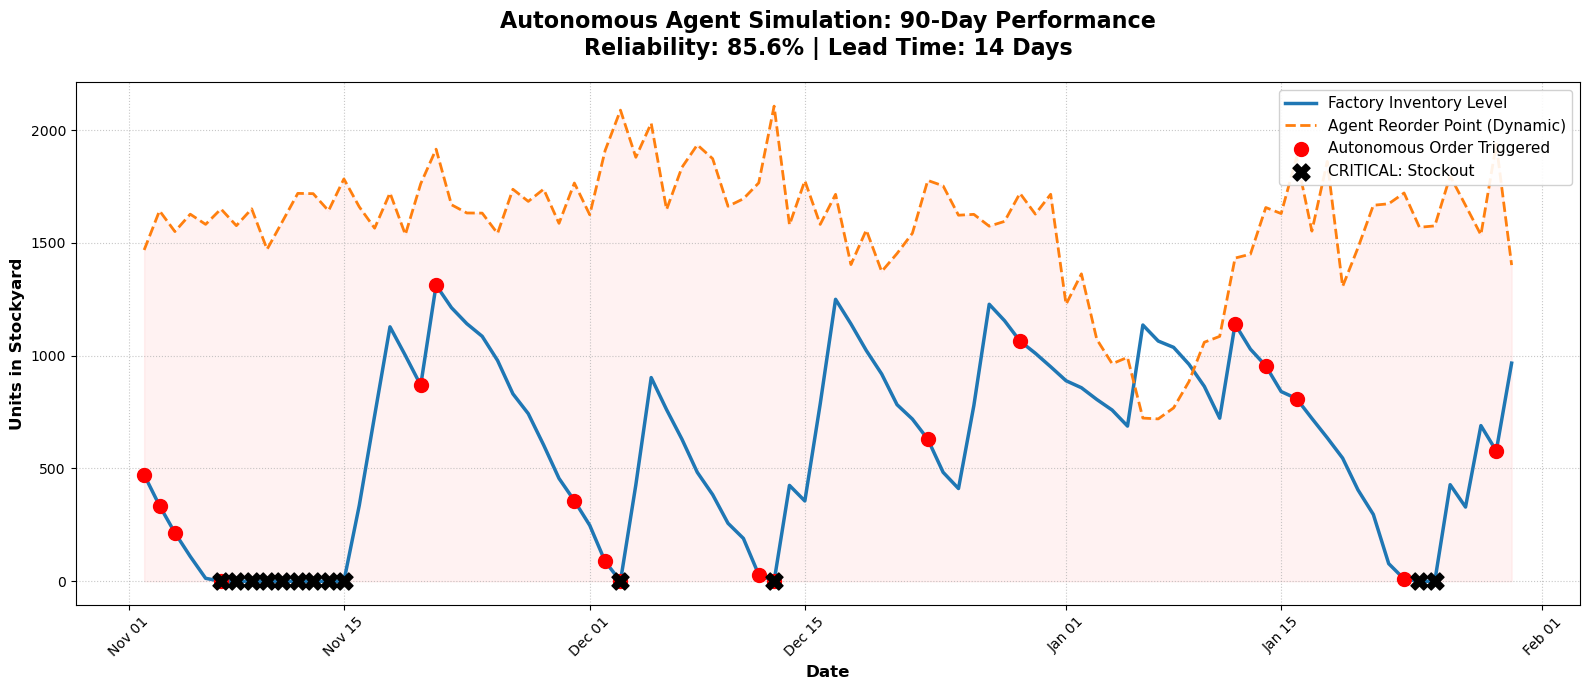

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# STEP 6: EXECUTIVE VISUALIZATION
# ==========================================
print("Generating Executive Dashboard...")

# Create the plot
fig, ax = plt.subplots(figsize=(16, 7))

# 1. Plot the actual inventory levels
ax.plot(results_df['date'], results_df['inventory_level'], 
        label='Factory Inventory Level', color='#1f77b4', linewidth=2.5)

# 2. Plot the dynamic reorder point (The Agent's "Safety Net")
ax.plot(results_df['date'], results_df['reorder_point'], 
        label='Agent Reorder Point (Dynamic)', color='#ff7f0e', linestyle='--', linewidth=2)

# 3. Highlight days where the agent triggered an order
order_days = results_df[results_df['order_placed'] == True]
ax.scatter(order_days['date'], order_days['inventory_level'], 
           color='red', s=100, zorder=5, label='Autonomous Order Triggered')

# 4. Highlight dangerous stockout zones (if any occurred)
stockout_days = results_df[results_df['inventory_level'] == 0]
if not stockout_days.empty:
    ax.scatter(stockout_days['date'], [0]*len(stockout_days), 
               color='black', marker='X', s=150, zorder=6, label='CRITICAL: Stockout')

# Formatting for a professional industrial look
ax.set_title(f"Autonomous Agent Simulation: 90-Day Performance\nReliability: {reliability_percentage:.1f}% | Lead Time: {SUPPLIER_LEAD_TIME} Days", 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel("Units in Stockyard", fontsize=12, fontweight='bold')
ax.set_xlabel("Date", fontsize=12, fontweight='bold')

# Format dates on X-axis nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

# Add grid and legend
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

# Fill the danger zone (below reorder point) lightly with red
ax.fill_between(results_df['date'], results_df['reorder_point'], 0, color='red', alpha=0.05)

plt.tight_layout()
plt.show()

In [6]:
pip install tabulate

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install langchain-google-genai

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
import pandas as pd
from dotenv import load_dotenv  
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate

# ==========================================
# STEP 7 & 8: THE OPTIMIZED LLM ENGINE
# ==========================================
print("Initializing Optimized Gemini Engine...")

# 1. Load the secrets securely from your .env file
# (This assumes you created the .env file in your folder as discussed)
load_dotenv(r"C:\Users\arman\OneDrive\Desktop\tata_steel_inventory_agent\backend\.env") 

# 2. Initialize the LLM 
# LangChain automatically finds GOOGLE_API_KEY from your .env file!
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash", temperature=0)

# 3. Build the Direct Prompt Template
template = """
You are the Autonomous Supply Chain Agent for Tata Steel.
The user is asking about an automated order placed on a specific date. 

Here is the exact factory simulation data extracted for that date:
{factory_data}

CRITICAL INSTRUCTIONS:
1. Provide a 1-2 sentence executive summary explaining the business risk of NOT ordering today (e.g., preventing a stockout).
2. Provide a bulleted list titled "Technical Metrics" showing the exact numbers from the data (Inventory Level, Reorder Point, Actual Consumption).

Do not write any code. Be highly professional and precise.
"""
prompt = PromptTemplate.from_template(template)

# Create the ultra-fast, single-call chain
chain = prompt | llm

print("Optimized Engine Ready!\n")

# ==========================================
# EXECUTE THE QUERY (Zero API Loops!)
# ==========================================
target_date = "2023-11-15"
user_question = f"Why did you trigger an automated purchase order on {target_date}?"
print(f"User: {user_question}\n")

# 4. Use standard Python to find the data instantly (Zero API calls used here)
day_data = results_df[results_df['date'].astype(str).str.contains(target_date)]

if day_data.empty:
    print("Agent: I have no record of an order on that date.")
else:
    # 5. Make EXACTLY ONE LLM call to write the final summary
    response = chain.invoke({"factory_data": day_data.to_dict('records')})
    print(f"Tata Steel Agent:\n{response.content}")

# ... (bottom of the new block) ...
target_date = "2023-11-15"
user_question = f"Why did you trigger an automated purchase order on {target_date}?"

# It uses chain.invoke now, not agent.invoke!
response = chain.invoke({"factory_data": day_data.to_dict('records')})

Initializing Optimized Gemini Engine...
Optimized Engine Ready!

User: Why did you trigger an automated purchase order on 2023-11-15?



ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [ ]:
# Show all days where the agent placed an order
results_df[results_df['order_placed'] == True]

,date,inventory_level,reorder_point,actual_consumption,order_placed
0,2023-11-02,472,1468.801136,128,True
1,2023-11-03,335,1642.673971,137,True
2,2023-11-04,215,1550.497655,120,True
5,2023-11-07,0,1650.626759,99,True
18,2023-11-20,869,1762.637106,132,True
19,2023-11-21,1313,1915.828192,56,True
28,2023-11-30,357,1765.709556,99,True
30,2023-12-02,88,1909.446553,160,True
31,2023-12-03,0,2088.780943,119,True
40,2023-12-12,29,1766.375962,161,True


In [ ]:
# ... (bottom of the new block) ...
target_date = "2023-11-15"
user_question = f"Why did you trigger an automated purchase order on {target_date}?"

# It uses chain.invoke now, not agent.invoke!
response = chain.invoke({"factory_data": day_data.to_dict('records')})